# Cuaderno de Clase — Introducción a Word Embeddings y Word2Vec

## Objetivo

Comprender cómo las representaciones vectoriales densas (embeddings) capturan significado semántico, y aprender a usar vectores Word2Vec pre-entrenados para explorar similitudes y analogías entre palabras.

## Resultados de aprendizaje

Al terminar este cuaderno vas a poder:

- Explicar por qué BoW y TF-IDF no capturan significado semántico.
- Describir el principio detrás de Word2Vec (hipótesis distribucional).
- Cargar un modelo de vectores pre-entrenados con `gensim`.
- Buscar palabras similares y construir analogías vectoriales.
- Identificar al menos una limitación crítica de Word2Vec.

## Relación con cuadernos anteriores

En el cuaderno anterior trabajamos con representaciones dispersas (BoW y TF-IDF): vectores donde cada dimensión corresponde a una palabra del vocabulario. Acá damos el salto a las representaciones densas, donde cada palabra ocupa un vector pequeño (típicamente 300 dimensiones) con información semántica distribuida.


## 1. Instalaciones e importaciones

Vamos a usar la librería `gensim`, que es la herramienta estándar para trabajar con vectores de palabras pre-entrenados (Word2Vec, FastText, GloVe).


In [6]:
# Instalamos gensim si no está disponible en el entorno
%pip install gensim -q


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# 'gensim' es la librería principal para trabajar con Word2Vec
import gensim

# 'KeyedVectors' permite cargar y consultar vectores pre-entrenados
from gensim.models import KeyedVectors

# 'numpy' para operaciones numéricas
import numpy as np

# Silenciamos advertencias menores para que la salida sea más limpia
import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente.")


Librerías importadas correctamente.


Gensim es una libreria para trabajar con word2vec, FastText y Glove. Importamos KeyedVectors  que es la clase dentro de gensim que representa un conjunto de vectores ya entrenados. 

## 2. ¿Por qué necesitamos algo mejor que BoW y TF-IDF?

Antes de ver cómo funcionan los embeddings, conviene recordar qué nos falta con los métodos anteriores.


Bow presentaba ausencia o presencia de una palabra en un texto creaba un vector y ponía 1 si aparecia y 0 sino. No distingue frecuencias  ni importancias por ejemplo , ¨el¨ es igual de importante que ¨algoritmo¨La problematica se intento resolver con  TF- IDF lo que hace es  ponderar si una palabra es mas relevante que otra y se calculaba en dos partes. Es el resultado del termino TF * IDF. TF mide que tan seguido aparece la palabra y IDF qué tan rara es la palabra en la colección. Pero sigue siendo insuficiente porque ambos NO capturan la similitud semantica, es decir, perro y gato son igual de distintos que perro y mesa. No se distingen sinonimos, posee alta dimensionalidad y vectores vacíos que genera un alto desperdicio computacional. Por último, no hay estructura de espacio.

# 3. La Idea Clave: Word Embeddings

¡Aquí entran los **Word Embeddings** (incrustaciones de palabras)!

*   **Idea Central:** Representar cada palabra como un **vector denso** (la mayoría de valores NO son cero) en un espacio de **menor dimensión** (ej: 50, 100, 300 dimensiones, ¡no 50,000!).
*   **La "Magia":** Estos vectores no son aleatorios. Se aprenden de grandes cantidades de texto de forma que palabras con **significados similares** terminan teniendo **vectores cercanos** en ese espacio vectorial.
    *   El vector de "gato" estará cerca del vector de "perro".
    *   El vector de "contento" estará cerca del vector de "feliz".
*   **Analogía:** Imaginen un mapa. Cada ciudad es una palabra. Las ciudades cercanas en el mapa representan palabras semánticamente relacionadas.
*   **¡Álgebra de Palabras!** Lo más sorprendente es que la estructura de este espacio vectorial captura relaciones semánticas y sintácticas de forma lineal. El ejemplo clásico:
    *   `vector('Rey') - vector('Hombre') + vector('Mujer') ≈ vector('Reina')`
    *   Podemos "operar" con los significados de las palabras usando sus vectores.

# 4. Word2Vec: Aprendiendo de los Vecinos (CBOW y Skip-gram)

Word2Vec (Mikolov et al., Google, 2013) fue uno de los métodos pioneros y más populares para aprender estos embeddings.

*   **Principio Fundamental (Hipótesis Distribucional):** *Una palabra se caracteriza por las compañías que mantiene*. Es decir, aprendemos el significado de una palabra observando las palabras que aparecen a su alrededor (su contexto).
*   **Arquitecturas (Redes Neuronales Superficiales):**
    *   **CBOW (Continuous Bag-of-Words):** Dado un conjunto de palabras de contexto (ej: las 2 palabras antes y las 2 después), intenta **predecir la palabra central**. Es más rápido de entrenar y bueno para palabras frecuentes.
        *   `[la, casa, ___, bonita] -> predecir 'es'`
    *   **Skip-gram:** Dada la palabra central, intenta **predecir las palabras de su contexto**. Es más lento pero generalmente funciona mejor con palabras infrecuentes y captura mejor relaciones semánticas más finas. Suele ser el preferido si el rendimiento es clave.
        *   `'es' -> predecir [la, casa, ___, bonita]`
*   **¿Cómo se aprende?:** La red neuronal (muy simple, usualmente una sola capa oculta) ajusta los vectores (embeddings) de entrada y salida para mejorar en la tarea de predicción (sea CBOW o Skip-gram). Los detalles técnicos (Negative Sampling, Hierarchical Softmax) son optimizaciones para hacerlo eficiente, pero la idea es que los vectores se ajustan para que palabras que aparecen en contextos similares terminen con vectores similares.
*   **Resultado:** Una "tabla de consulta" (o diccionario) donde cada palabra del vocabulario tiene asociado un vector denso aprendido (el embedding).

# 5. Usando Vectores Pre-entrenados (¡Importante!)

Entrenar modelos Word2Vec (o GloVe, FastText) desde cero requiere:
1.  **Muchísimo texto:** Millones o miles de millones de palabras (ej: toda la Wikipedia, noticias de años).
2.  **Mucho tiempo computacional:** Horas o días, incluso con hardware potente.

**¡La buena noticia!** Investigadores y empresas ya han hecho este trabajo pesado y publican los **modelos pre-entrenados**. Nosotros podemos simplemente descargarlos y usarlos.

Para español, una fuente común y de buena calidad son los vectores entrenados sobre el **Spanish Billion Words Corpus (SBWC)** por la Universidad de Chile. También hay otros, como los de FastText.

**Tarea:** Necesitamos descargar uno de estos archivos. Busquen en la web "Spanish Word Embeddings SBWC download" o similar.
*   Recomendado: Descargar el archivo `.bin` (formato binario, más compacto) si está disponible. Si no, el `.vec` (formato texto). Suelen ser archivos grandes (varios GB!).
*   **Importante:** Una vez descargado, anoten la ruta completa donde guardaron el archivo en su máquina o Google Drive.

[Spanish Word Embeddings SBWC download](https://github.com/dccuchile/spanish-word-embeddings?tab=readme-ov-file) [Mirror](https://drive.google.com/file/d/1rSI0q8J_USo1GpPfzUOa7pNgmLc66svv/edit)

# 6. Cargando Vectores con Gensim

Una vez que tenemos el archivo (`.bin` o `.vec`), usamos `gensim` para cargarlo.

**¡Reemplacen `'RUTA_AL_ARCHIVO_DESCARGADO.bin'` con la ruta real donde guardaron el archivo!**

Si están en Colab, pueden subir el archivo a su sesión (tardará si es grande) o montarlo desde Google Drive.

## 3. Carga del modelo de vectores pre-entrenados

Vamos a usar el corpus **Spanish Billion Words** (SBWC), un modelo Word2Vec entrenado sobre miles de millones de palabras en español.

El archivo ya está disponible en la carpeta `vectors/` de este módulo. No hace falta descargarlo.

> **Nota técnica:** el formato `.bin.gz` es el formato binario comprimido de Word2Vec. Al usar `binary=True`, `gensim` sabe que tiene que descomprimirlo y leerlo en ese formato.


In [8]:
import os

# Ruta al archivo de vectores pre-entrenados
# El archivo está en la subcarpeta 'vectors/' dentro de este módulo
ruta_vectores = r"C:\dominguez-micaela-belen-pln-1c-2026\010\002-PRA\vectors\SBW-vectors-300-min5.bin.gz"
# Si el path automático no funciona, podés reemplazarlo por una ruta absoluta:
# ruta_vectores = r"E:\IFTS24-Cuadernos 2026\ifts24-lab-pln-2026\010_representaciones_semanticas_parte2\vectors\SBW-vectors-300-min5.bin.gz"

print(f"Ruta configurada: {ruta_vectores}")
print(f"El archivo existe: {os.path.exists(ruta_vectores)}")


Ruta configurada: C:\dominguez-micaela-belen-pln-1c-2026\010\002-PRA\vectors\SBW-vectors-300-min5.bin.gz
El archivo existe: True


In [9]:
# Intentamos cargar el modelo de vectores
# Este proceso puede tardar algunos minutos la primera vez (el archivo es grande)
try:
    print("Cargando vectores... (puede tardar unos minutos)")
    word_vectors = KeyedVectors.load_word2vec_format(ruta_vectores, binary=True)
    total_palabras = len(word_vectors.index_to_key)
    dimension = word_vectors.vector_size
    print(f"Vectores cargados correctamente.")
    print(f"Vocabulario: {total_palabras} palabras.")
    print(f"Dimensión de cada vector: {dimension}.")

except FileNotFoundError:
    print(f"No se encontró el archivo en: {ruta_vectores}")
    print("Verificá que el archivo esté en la carpeta 'vectors/' del módulo.")
    word_vectors = None

except Exception as e:
    print(f"Error inesperado al cargar: {e}")
    word_vectors = None


Cargando vectores... (puede tardar unos minutos)
Vectores cargados correctamente.
Vocabulario: 1692025 palabras.
Dimensión de cada vector: 300.


## 4. Explorando los vectores

Si el modelo se cargó correctamente, podemos empezar a explorar qué contiene. Vamos a verificar si algunas palabras están en el vocabulario.

> **Para mirar:** ¿todas las palabras que intentamos están en el vocabulario? ¿Hay alguna que no esté? ¿Por qué creés que puede pasar eso?


In [12]:
if word_vectors is not None:
    print("Verificando palabras en el vocabulario...")

    # Consultamos si cada palabra está presente en el modelo
    palabras_a_verificar = [' rey', 'programacion', 'programación', 'casa', 'qwerty', 'Cortazar']

    for palabra in palabras_a_verificar:
        esta_presente = palabra in word_vectors
        print(f"  '{palabra}' en vocabulario: {esta_presente}")
else:
    print("El modelo no está cargado. Por favor, revisá la celda anterior.")


Verificando palabras en el vocabulario...
  ' rey' en vocabulario: False
  'programacion' en vocabulario: True
  'programación' en vocabulario: True
  'casa' en vocabulario: True
  'qwerty' en vocabulario: True
  'Cortazar' en vocabulario: True


Aparecen todas las palabras. Esto pasa porque el moduelo fue entrando con mucho texto. Pruebo con una palabra inventada a ver que es lo que obtengo. Obtuve false.

### Obtener el vector de una palabra

Cada palabra en el vocabulario tiene asociado un vector numérico de 300 dimensiones. Veamos cómo se ve uno de esos vectores.

> **Para mirar:** ¿qué forma tiene el vector? ¿Los números tienen algún rango típico?


Es un array de 300 dimensiones es decir  cada valor  especifica un lugar semantico. El vector es denso y   los valores son pequeños y casi nunca exactamente 0

In [13]:
if word_vectors is not None:
    # Verificamos que la palabra esté antes de pedir su vector
    palabra_a_buscar = 'Borges'

    if palabra_a_buscar in word_vectors:
        vector_rey = word_vectors[palabra_a_buscar]
        cantidad_dimensiones = vector_rey.shape[0]
        print(f"Dimensiones del vector de '{palabra_a_buscar}': {cantidad_dimensiones}")
        print(f"Primeros 10 valores del vector: {vector_rey[:200]}")
    else:
        print(f"La palabra '{palabra_a_buscar}' no está en el vocabulario.")
else:
    print("El modelo no está cargado. Por favor, revisá la celda anterior.")


Dimensiones del vector de 'Borges': 300
Primeros 10 valores del vector: [ 0.27834547  0.35622352 -0.13389401 -0.04102119 -0.18645516  0.10934287
 -0.12960358  0.12010721 -0.01294594  0.28309014  0.13587232  0.06262053
  0.36250368  0.18937561 -0.1517196   0.14090697 -0.28856465 -0.11011202
  0.1685098   0.13617736  0.46179622  0.12880515  0.10379276 -0.19195072
  0.1186656   0.05963394  0.17545192 -0.05360803 -0.3945479  -0.23601681
  0.00742186 -0.19129841 -0.7091245  -0.06221411 -0.25212908 -0.04674497
  0.29483414 -0.0691446   0.03617019 -0.1336416   0.21639428 -0.09485412
  0.24084821  0.04337193 -0.12226369  0.2572383  -0.03133043 -0.16583988
 -0.15165791  0.05243601  0.1181258   0.12235086 -0.10166603 -0.26647258
  0.17615344  0.12818019  0.3886712  -0.07160924  0.25149885 -0.09082778
 -0.07302633 -0.06191121  0.03306605  0.17583284  0.26911995  0.3904448
 -0.23856659  0.17128275  0.292698   -0.36306813 -0.19472024  0.26339078
  0.24480155  0.10021811  0.09096261 -0.30243152 -0.3

### Encontrar palabras similares

El método `most_similar()` devuelve las palabras cuyo vector es más cercano al de la palabra buscada. La cercanía se mide con similitud coseno (un valor entre 0 y 1, donde 1 es idéntico).

> **Para mirar:** ¿te parecen lógicas las palabras más similares? ¿Hay alguna sorprendente?


In [14]:
if word_vectors is not None:
    print("Palabras más similares según el modelo:")
    print()

    # Buscamos las 5 palabras más similares a 'rey'
    try:
        similares_rey = word_vectors.most_similar('Borges', topn=5)
        print("Más similares a 'Borges':")
        for palabra, puntaje in similares_rey:
            print(f"  {palabra}: {puntaje:.4f}")
    except KeyError:
        print("La palabra 'Borges' no está en el vocabulario.")

    print()

    # Buscamos las 5 palabras más similares a 'perro'
    try:
        similares_perro = word_vectors.most_similar('perro', topn=5)
        print("Más similares a 'perro':")
        for palabra, puntaje in similares_perro:
            print(f"  {palabra}: {puntaje:.4f}")
    except KeyError:
        print("La palabra 'perro' no está en el vocabulario.")
else:
    print("El modelo no está cargado.")


Palabras más similares según el modelo:

Más similares a 'Borges':
  Bioy: 0.7091
  Jorge_Luis_Borges: 0.7056
  Onetti: 0.6658
  Macedonio_Fernández: 0.6631
  Bioy_Casares: 0.6626

Más similares a 'perro':
  gato: 0.8182
  cachorro: 0.7781
  oso: 0.7136
  perrito: 0.7128
  rottweiler: 0.7068


De perro las palabras mas similares puede ser porque pertenezcan al espacio animal. Borges no estarian siendo exactamente sinonimos sino que mas bien comparten el contexto de la literatura.

In [15]:
if word_vectors is not None:
    # Algunas palabras pueden estar en el vocabulario en una variante ortográfica
    # Verificamos cuál versión está disponible antes de buscar
    variantes_compu = ['computadora', 'computador']
    palabra_encontrada = None

    for variante in variantes_compu:
        if variante in word_vectors:
            palabra_encontrada = variante
            break

    if palabra_encontrada is not None:
        similares_compu = word_vectors.most_similar(palabra_encontrada, topn=5)
        print(f"Más similares a '{palabra_encontrada}':")
        for palabra, puntaje in similares_compu:
            print(f"  {palabra}: {puntaje:.4f}")
    else:
        print("No se encontró 'computadora' ni 'computador' en el vocabulario.")
else:
    print("El modelo no está cargado.")


Más similares a 'computadora':
  ordenador: 0.8642
  computador: 0.8271
  computadoras: 0.7330
  portátil: 0.7058
  ordenadores: 0.7028


Las palabras mas similares a computadora son sinonimos o variantes de la misma palabra. Lo que muestra es que agrupa terminos que aparecen bajoi el mismo contexto pero de distintas variantes del español


## 5. Analogías vectoriales — el álgebra de palabras

Una de las propiedades más llamativas de los embeddings es que permiten hacer operaciones matemáticas con significado. La analogía clásica es:

> **rey − hombre + mujer ≈ reina**

Lo que estamos haciendo es: tomamos el vector de "rey", le restamos el vector de "hombre" (sacamos la parte "masculinidad") y le sumamos el vector de "mujer". El vector resultante debería estar cerca de "reina".

> **Para mirar:** ¿funcionan las analogías como esperabas? ¿Cuál te parece más acertada y cuál menos?


In [16]:
if word_vectors is not None:
    print("Probando analogías vectoriales...")
    print()

    # Analogía 1: rey - hombre + mujer = ? (esperamos: reina)
    palabras_necesarias_1 = ['rey', 'hombre', 'mujer']
    palabras_faltantes_1 = []
    for palabra in palabras_necesarias_1:
        if palabra not in word_vectors:
            palabras_faltantes_1.append(palabra)

    if len(palabras_faltantes_1) == 0:
        resultado_1 = word_vectors.most_similar(positive=['rey', 'mujer'], negative=['hombre'], topn=1)
        print(f"rey - hombre + mujer = {resultado_1[0][0]} (puntaje: {resultado_1[0][1]:.4f})")
    else:
        print(f"Faltan palabras para esta analogía: {palabras_faltantes_1}")

    print()

    # Analogía 2: España - Madrid + París = ? (esperamos: Francia)
    palabras_necesarias_2 = ['españa', 'madrid', 'parís']
    palabras_faltantes_2 = []
    for palabra in palabras_necesarias_2:
        if palabra not in word_vectors:
            palabras_faltantes_2.append(palabra)

    if len(palabras_faltantes_2) == 0:
        resultado_2 = word_vectors.most_similar(positive=['españa', 'parís'], negative=['madrid'], topn=1)
        print(f"España - Madrid + París = {resultado_2[0][0]} (puntaje: {resultado_2[0][1]:.4f})")
    else:
        print(f"Faltan palabras para esta analogía: {palabras_faltantes_2}")

    print()

    # Analogía 3: correr - corriendo + comiendo = ? (esperamos: comer)
    palabras_necesarias_3 = ['correr', 'corriendo', 'comiendo']
    palabras_faltantes_3 = []
    for palabra in palabras_necesarias_3:
        if palabra not in word_vectors:
            palabras_faltantes_3.append(palabra)

    if len(palabras_faltantes_3) == 0:
        resultado_3 = word_vectors.most_similar(positive=['correr', 'comiendo'], negative=['corriendo'], topn=1)
        print(f"correr - corriendo + comiendo = {resultado_3[0][0]} (puntaje: {resultado_3[0][1]:.4f})")
    else:
        print(f"Faltan palabras para esta analogía: {palabras_faltantes_3}")
else:
    print("El modelo no está cargado.")


Probando analogías vectoriales...

rey - hombre + mujer = reina (puntaje: 0.7546)

España - Madrid + París = Cordon_Bleu (puntaje: 0.4550)

correr - corriendo + comiendo = comer (puntaje: 0.6456)


La primera y la ultima si funcionaron. Pero la del medio no me parece inclusive tiene valores bajos de puntaje. Supongo que el modelo  se da cuenta que no esta capturando bien la analogia  o no esta seguro del resultado.

## 6. Similitud coseno entre palabras

Además de encontrar las palabras más similares, podemos calcular un número exacto que representa qué tan parecidas son dos palabras. Ese número se llama **similitud coseno** y va de 0 (nada parecidas) a 1 (idénticas).

> **Para mirar:** ¿los valores tienen sentido? ¿La similitud entre antónimos (como "grande" y "pequeño") es alta o baja? ¿Por qué?


In [18]:
if word_vectors is not None:
    print("Similitudes coseno entre pares de palabras:")
    print()

    # Pares a comparar: (palabra_a, palabra_b, descripcion)
    pares = [
        ('perro', 'gato', 'animales domésticos'),
        ('perro', 'mesa', 'sin relación obvia'),
        ('estudiante', 'alumno', 'sinónimos'),
        ('grande', 'pequeño', 'antónimos'),
    ]

    for palabra_a, palabra_b, descripcion in pares:
        if palabra_a in word_vectors and palabra_b in word_vectors:
            similitud = word_vectors.similarity(palabra_a, palabra_b)
            print(f"  Similitud('{palabra_a}', '{palabra_b}') [{descripcion}]: {similitud:.4f}")
        else:
            print(f"  Alguna de las palabras '{palabra_a}'/'{palabra_b}' no está en el vocabulario.")
else:
    print("El modelo no está cargado.")


Similitudes coseno entre pares de palabras:

  Similitud('perro', 'gato') [animales domésticos]: 0.8182
  Similitud('perro', 'mesa') [sin relación obvia]: 0.2626
  Similitud('estudiante', 'alumno') [sinónimos]: 0.7507
  Similitud('grande', 'pequeño') [antónimos]: 0.6749


Los antónimos grande y pequeño tienen una similitud alta 0.6749 porque aunque son opuestos en significado, aparecen en los mismos contextos en el texto

## 7. Visualización de embeddings (opcional)

Los vectores de palabras tienen 300 dimensiones, pero nosotros solo podemos visualizar en 2 o 3 dimensiones. Para eso usamos **t-SNE**, una técnica que reduce la dimensionalidad preservando (en lo posible) las relaciones de cercanía entre vectores.

> **Para mirar:** ¿las palabras de temas similares quedan cerca en el gráfico? ¿Qué grupos aparecen?


  File "c:\dominguez-micaela-belen-pln-1c-2026\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\dominguez-micaela-belen-pln-1c-2026\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\domin\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\domin\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\domin\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable

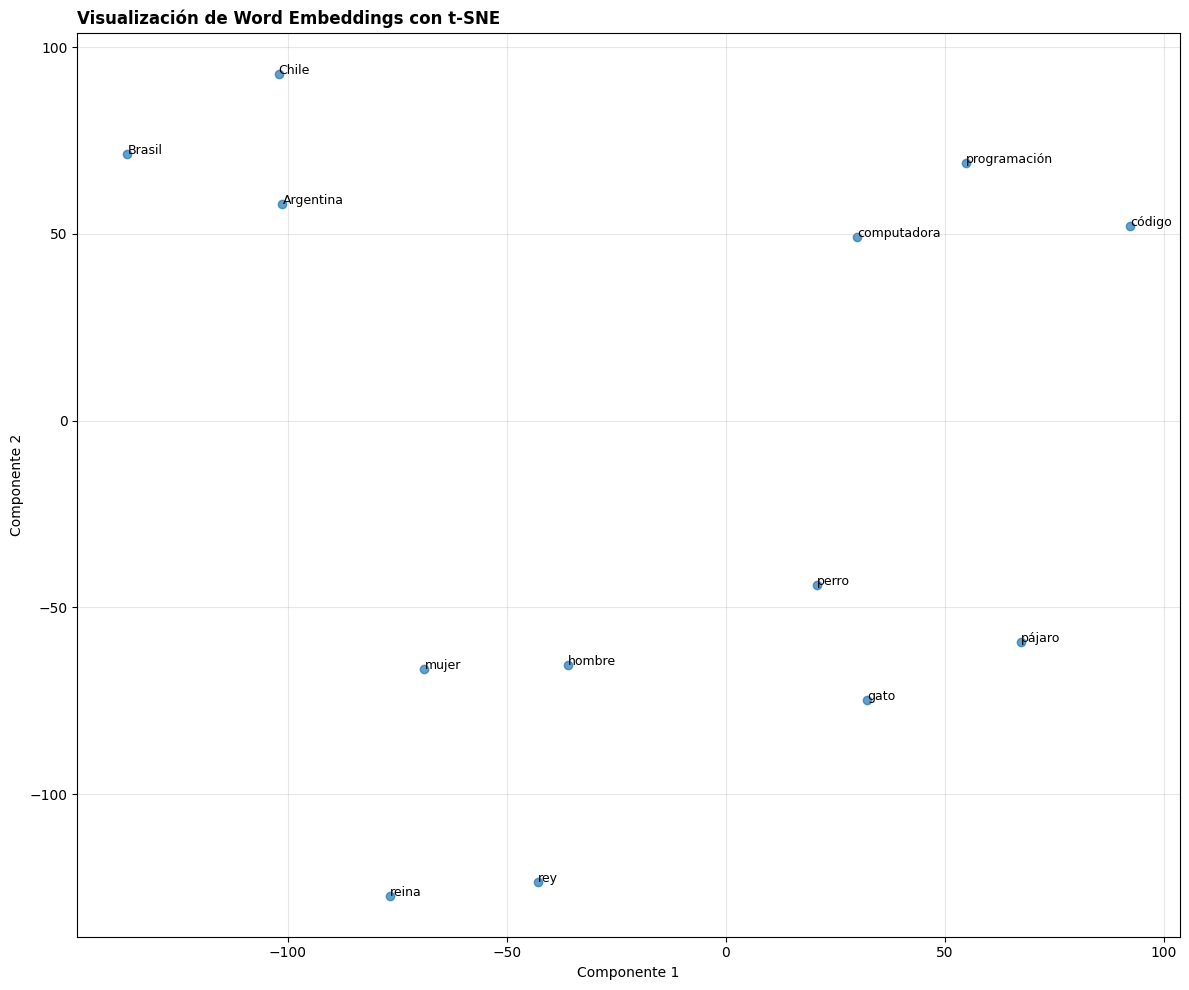

Se visualizaron 13 palabras.


In [19]:
if word_vectors is not None:
    import matplotlib.pyplot as plt
    from sklearn.manifold import TSNE
    import numpy as np

    # Lista de palabras a visualizar
    palabras_a_visualizar = [
        'rey', 'reina', 'hombre', 'mujer',
        'perro', 'gato', 'pájaro',
        'Argentina', 'Brasil', 'Chile',
        'computadora', 'programación', 'código'
    ]

    # Filtramos solo las palabras que estén en el vocabulario
    palabras_presentes = []
    for palabra in palabras_a_visualizar:
        if palabra in word_vectors:
            palabras_presentes.append(palabra)

    if len(palabras_presentes) >= 3:
        # Obtenemos el vector de cada palabra presente
        vectores_presentes = []
        for palabra in palabras_presentes:
            vectores_presentes.append(word_vectors[palabra])

        # Convertimos a array numpy
        import numpy as np
        matriz_vectores = np.array(vectores_presentes)

        # Reducimos de 300 a 2 dimensiones con t-SNE
        # 'perplexity' controla cuántos vecinos se consideran; para pocos puntos conviene un valor bajo
        modelo_tsne = TSNE(n_components=2, perplexity=5, random_state=42)
        vectores_2d = modelo_tsne.fit_transform(matriz_vectores)

        # Graficamos
        fig, ax = plt.subplots(figsize=(12, 10))
        ax.scatter(vectores_2d[:, 0], vectores_2d[:, 1], alpha=0.7)

        # Etiquetamos cada punto con el nombre de la palabra
        for i in range(len(palabras_presentes)):
            ax.annotate(palabras_presentes[i], (vectores_2d[i, 0], vectores_2d[i, 1]), fontsize=9)

        ax.set_title("Visualización de Word Embeddings con t-SNE", fontweight="bold", loc="left")
        ax.set_xlabel("Componente 1")
        ax.set_ylabel("Componente 2")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        cantidad_visualizada = len(palabras_presentes)
        print(f"Se visualizaron {cantidad_visualizada} palabras.")
    else:
        print("No hay suficientes palabras en el vocabulario para visualizar.")
else:
    print("El modelo no está cargado.")


ok si se visualiza la forma en que se agrupan por contexto 

# 9. Micro-Laboratorio (Ejercicio Práctico)

**Consigna:** (Asumiendo que `word_vectors` se cargó correctamente)

1.  **Exploración de Similitud:**
    *   Elegí 5 palabras que les interesen (intenten variar: un lugar, una profesión, un concepto abstracto, una comida, un sentimiento).
    *   Para cada una, usar `word_vectors.most_similar()` para encontrar las 5 palabras más parecidas.
    *   Anotá los resultados. ¿Les parecen lógicos? ¿Hay alguna similitud sorprendente o extraña?

2.  **Prueba de Analogías:**
    *   Inventá y probá 3 analogías diferentes usando `word_vectors.most_similar(positive=[...], negative=[...])`.
    *   Ideas:
        *   `programador` es a `computadora` como `médico` es a `?`
        *   `Argentina` es a `peso` como `Japón` es a `?`
        *   `caminar` es a `pierna` como `hablar` es a `?`
    *   Verificá que todas las palabras de la analogía estén en el vocabulario antes de probarla.
    *   Anotá los resultados. ¿Funcionan las analogías como esperaban?

3.  **(Opcional) Medir Similitud:**
    *   Elegí 3 pares de palabras:
        *   Un par de sinónimos claros (ej: `estudiante`, `alumno`).
        *   Un par de antónimos (ej: `grande`, `pequeño`).
        *   Un par de palabras no relacionadas (ej: `nube`, `zapato`).
    *   Calculá `word_vectors.similarity()` para cada par.
    *   ¿Los valores de similitud reflejan la relación entre las palabras? (Esperamos alta para sinónimos, baja/media-baja para no relacionadas, y ¿qué pasa con antónimos?).

**¡Asegúrense de que las palabras que usan existan en `word_vectors`!**

In [ ]:
palabras = ['terremoto', 'libro', 'ingeniero', 'fútbol', 'obsesión', 'asado']
# recorro el array de strings si esta en word_vectors  que me traiga las mas similares top 5 con el metodo most_similar()
for palabra in palabras:
    if palabra in word_vectors:
        similares = word_vectors.most_similar(palabra, topn=5)
        print(f"\nMás similares a '{palabra}':")
        for p, puntaje in similares:
            print(f"  {p}: {puntaje:.4f}")
    else:
        print(f"\n'{palabra}' no está en el vocabulario.")


Más similares a 'terremoto':
  sismo: 0.8638
  seísmo: 0.8118
  maremoto: 0.8080
  tsunami: 0.8013
  Loma_Prieta: 0.7123

Más similares a 'libro':
  poema: 0.7067
  relato: 0.6851
  poemario: 0.6814
  cuento: 0.6806
  manuscrito: 0.6799

Más similares a 'ingeniero':
  agrónomo: 0.7446
  arquitecto: 0.7008
  Ingeniero: 0.6828
  Eduardo_Torroja_Miret: 0.6587
  José_Eugenio_Ribera: 0.6510

Más similares a 'fútbol':
  voleibol: 0.7758
  baloncesto: 0.7723
  balonmano: 0.7694
  futbol: 0.7684
  rugby: 0.7564

Más similares a 'obsesión':
  fascinación: 0.7470
  pasión: 0.6843
  ambición: 0.6463
  obsesiva: 0.6413
  compulsión: 0.6392

Más similares a 'asado':
  guisado: 0.8231
  asada: 0.8175
  guiso: 0.8098
  chorizo: 0.8031
  pollo: 0.8026


Elegí 6 palabras: terremoto, libro, ingeniero, fútbol, obsesión y asado. En todos los casos las palabras similares pertenecen al mismo campo semántico. Para mí el resultado que más me llamó la atención fue el de ingeniero, que trajo palabras similares de carreras y nombres de ingenieros famosos. Me llama la atención también que hasta respetó el sexo, no nombró ingenieras. Es interesante porque investigué acerca de estos dos ingenieros y son referentes de España, así que demuestra también el sesgo geográfico que tiene el modelo al haber sido entrenado en su mayor proporción por textos en español de España

# 10. Brainstorming: Sesgos en Embeddings

Hemos visto que los embeddings capturan relaciones del lenguaje tal como aparecen en los datos de entrenamiento (el corpus masivo).

**Pregunta clave:** Si esos datos contienen **sesgos sociales** (de género, raciales, de profesión, etc.), ¿qué creen que pasará con los embeddings?

*   ¿Se reflejarán esos sesgos en las relaciones entre vectores? (Pista: ¡Sí!)
    *   Ejemplo famoso: `doctor - hombre + mujer = ?` a veces da `enfermera` en modelos entrenados en textos antiguos o sesgados. `programador - hombre + mujer = ?` podía dar `ama de casa`.
*   ¿Qué implicancias tiene esto si usamos estos embeddings para tareas como selección de personal, análisis de opiniones, o generación de texto?
*   Si el corpus no representa bien la diversidad lingüística (dialectos, jergas, lenguaje inclusivo), ¿cómo afectará eso a los embeddings de esas palabras (si es que existen)?
*   **¿Cómo podemos entrenar word embeddings que sean más inclusivos y representativos?** ¿Es posible "limpiar" o "corregir" (debias) los embeddings pre-entrenados? ¿Es nuestra responsabilidad como desarrolladores ser conscientes de esto y mitigarlo?

**(Discusión en grupo)**

Si. Si usamos esos embbedings probablemente las decisiones finales no sean las mas adecuadas o estarian sesgadas. Quizas no tengan vector asociado. Si se puede curar el corpus de entrenamiento.

# GUÍA DE ESTUDIO - WORD EMBEDDINGS Y WORD2VEC

## Preguntas y Respuestas Clave

### **Revolución Conceptual**

**P: ¿Cuál es la diferencia fundamental entre BoW/TF-IDF y Word Embeddings?**  
R: BoW/TF-IDF crea vectores dispersos de alta dimensión (una por palabra del vocabulario). Word Embeddings crea vectores densos de baja dimensión (ej: 300) donde palabras similares están cerca geométricamente.

**P: ¿Qué significa que los embeddings capturen "semántica"?**  
R: Que palabras con significados similares tienen vectores similares. "auto" y "coche" estarán cerca en el espacio vectorial, no en dimensiones separadas.

**P: ¿Qué es la "álgebra de palabras" en embeddings?**  
R: La capacidad de hacer operaciones matemáticas que preservan relaciones semánticas: vector('rey') - vector('hombre') + vector('mujer') ≈ vector('reina').

### **Arquitecturas Word2Vec**

**P: ¿Cuál es la diferencia entre CBOW y Skip-gram?**  
R: CBOW predice palabra central dado contexto (rápido, bueno para palabras frecuentes). Skip-gram predice contexto dada palabra central (lento, mejor para palabras raras).

**P: ¿Qué es la "hipótesis distribucional"?**  
R: "Una palabra se conoce por las compañías que mantiene". Palabras que aparecen en contextos similares tienen significados similares.

### **Implementación Práctica**

**P: ¿Por qué usamos vectores pre-entrenados en lugar de entrenar desde cero?**  
R: Entrenar requiere corpus masivos (millones de palabras) y días de computación. Los modelos pre-entrenados ya capturan patrones del idioma.

**P: ¿Qué hace gensim.KeyedVectors?**  
R: Permite cargar y manipular vectores pre-entrenados sin necesidad de re-entrenar. Incluye funciones para similitud y analogías.

**P: ¿Cómo verificar si una palabra está en el vocabulario?**  
R: `palabra in word_vectors` antes de usar most_similar() o similarity() para evitar errores.

### **Análisis Semántico**

**P: ¿Qué indica un valor de similitud coseno alto entre dos palabras?**  
R: Que sus vectores apuntan en direcciones similares, sugiriendo relación semántica. Valores entre 0.3-0.7 son típicamente significativos.

**P: ¿Por qué algunas analogías funcionan mejor que otras?**  
R: Depende de qué tan consistentemente aparezcan esas relaciones en el corpus de entrenamiento. Relaciones muy frecuentes se capturan mejor.

### **Limitaciones Importantes**

**P: ¿Qué es el problema OOV (Out-of-Vocabulary)?**  
R: Palabras no vistas durante entrenamiento no tienen vector. Word2Vec clásico no puede manejar palabras nuevas, errores tipográficos, o neologismos.

**P: ¿Cómo reflejan sesgos los embeddings?**  
R: Si el corpus contiene sesgos sociales, los vectores los perpetúan. "doctor - hombre + mujer" podría dar "enfermera" en modelos sesgados.

## Puntos Clave para Recordar

1. **Word2Vec captura semántica** que BoW/TF-IDF ignora completamente
2. **Vectores densos de 300D > vectores dispersos de 50,000D**
3. **Similitud geométrica = similitud semántica**
4. **Analogías revelan estructura del lenguaje capturada**
5. **Siempre verificar vocabulario** antes de usar palabras
6. **Modelos pre-entrenados son la norma** para uso práctico

## Errores Comunes a Evitar

- Intentar usar palabras no presentes en vocabulario sin verificar
- Esperar que analogías muy específicas siempre funcionen
- Ignorar sesgos inherentes en modelos pre-entrenados
- Comparar palabras muy diferentes y esperar similitud alta
- No considerar que el modelo refleja el corpus de entrenamiento

## Conexión con Próxima Clase

Word2Vec tiene limitaciones: problema OOV y vocabulario fijo. La próxima clase explorará **FastText** y **GloVe**: arquitecturas que resuelven estos problemas y manejan palabras desconocidas.

---
*Consejo: Experimenta con analogías culturales argentinas: "Messi - fútbol + música = ?". ¿El modelo captura relaciones culturales locales?*

## Próximos pasos

En el siguiente cuaderno vamos a explorar dos alternativas a Word2Vec:

- **GloVe**: un enfoque basado en estadísticas globales de co-ocurrencia.
- **FastText**: una extensión que resuelve el problema de palabras fuera del vocabulario (OOV) usando n-gramas de caracteres.
